In [1]:
# !pip install torch
# !pip install torchvision

In [2]:
import copy
import warnings

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

warnings.filterwarnings("ignore")


# Data Loading

[data] MNIST

https://en.wikipedia.org/wiki/MNIST_database

In [3]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            (0.5,),  # 평균 0.5
            (0.5,),  # 표준편차 0.5
        ),
    ]
)

In [4]:
train_set = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_set = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

In [5]:
# train_set 중 일부를 validation set으로 분리 (train 90% / valid 10%)
valid_ratio = 0.1
train_size = int(len(train_set) * (1 - valid_ratio))
valid_size = len(train_set) - train_size

train_subset, valid_subset = torch.utils.data.random_split(
    train_set,
    [train_size, valid_size],
    generator=torch.Generator().manual_seed(42),
)

In [6]:
print(f"train_set size: {len(train_subset)}")
print(f"valid_set size: {len(valid_subset)}")
print(f"test_set size: {len(test_set)}")

train_set size: 54000
valid_set size: 6000
test_set size: 10000


In [7]:
train_loader = torch.utils.data.DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True,
)

valid_loader = torch.utils.data.DataLoader(
    valid_subset,
    batch_size=32,
    shuffle=False,
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=32,
    shuffle=False,
)


# Architecture

In [8]:
class CNN(nn.Module):
    def __init__(self, dropout_p=0.5):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.dropout_conv = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout_fc = nn.Dropout(dropout_p)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout_conv(x)
        x = x.view(-1, 64 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = self.fc2(x)
        return x


# Training

#### Setting

In [9]:
lr = 0.001
patience = 3  # early stopping: valid loss가 이 횟수만큼 연속으로 개선되지 않으면 학습 중단

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

### Training

In [12]:
num_epochs = 10
train_losses = []
valid_losses = []
valid_accuracies = []

**Early Stopping**

- 매 epoch마다 valid loss가 이전 최고 기록(best_valid_loss)보다 개선되었는지 확인
    - 개선되면 : best_valid_loss 갱신, 현재 가중치를 best_model_state로 저장, patience_counter 초기화
    - 개선되지 않으면 : patience_counter 1 증가
- patience_counter가 patience(=3)에 도달하면 num_epochs를 다 채우기 전에 학습 중단
- 학습 종료 후 best_model_state를 모델에 다시 로드하여, 가장 성능이 좋았던 시점의 가중치로 평가 진행


In [13]:
best_valid_loss = float("inf")
best_model_state = None
patience_counter = 0

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # ---- Validation ----
    model.eval()
    valid_running_loss = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            valid_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            valid_total += labels.size(0)
            valid_correct += (predicted == labels).sum().item()

    valid_losses.append(valid_running_loss / len(valid_loader))
    valid_accuracies.append(valid_correct / valid_total)

    print(
        f"Epoch {epoch + 1}, "
        f"Train Loss: {train_losses[-1]:.4f}, "
        f"Valid Loss: {valid_losses[-1]:.4f}, "
        f"Valid Accuracy: {valid_accuracies[-1]:.4f}"
    )

    # ---- Early Stopping ----
    if valid_losses[-1] < best_valid_loss:
        best_valid_loss = valid_losses[-1]
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(
                f"Early stopping at epoch {epoch + 1} "
                f"(best valid loss: {best_valid_loss:.4f})"
            )
            break

# 가장 valid loss가 낮았던 시점의 가중치로 복원
if best_model_state is not None:
    model.load_state_dict(best_model_state)


Epoch 1, Train Loss: 0.2464, Valid Loss: 0.0691, Valid Accuracy: 0.9808
Epoch 2, Train Loss: 0.1008, Valid Loss: 0.0497, Valid Accuracy: 0.9863
Epoch 3, Train Loss: 0.0780, Valid Loss: 0.0484, Valid Accuracy: 0.9857
Epoch 4, Train Loss: 0.0640, Valid Loss: 0.0428, Valid Accuracy: 0.9887
Epoch 5, Train Loss: 0.0609, Valid Loss: 0.0400, Valid Accuracy: 0.9877
Epoch 6, Train Loss: 0.0529, Valid Loss: 0.0388, Valid Accuracy: 0.9885
Epoch 7, Train Loss: 0.0455, Valid Loss: 0.0344, Valid Accuracy: 0.9897
Epoch 8, Train Loss: 0.0434, Valid Loss: 0.0335, Valid Accuracy: 0.9907
Epoch 9, Train Loss: 0.0400, Valid Loss: 0.0432, Valid Accuracy: 0.9897
Epoch 10, Train Loss: 0.0366, Valid Loss: 0.0335, Valid Accuracy: 0.9898


# Evaluation

In [14]:
def evaluate(model, loader, collect_misclassified=False):
    """loader에 대한 accuracy를 계산. collect_misclassified=True면 오분류 샘플도 함께 수집"""
    model.eval()
    correct = 0
    total = 0
    misclassified = []

    # eval 단계에서는 gradient 계산 불필요
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            # 가장 높은 확률을 가진 클래스 선택
            _, predicted = torch.max(outputs, 1)

            # 전체 샘플수 누적
            total += labels.size(0)

            # 정답과 예측이 일치하는 샘플수 누적
            correct += (predicted == labels).sum().item()

            if collect_misclassified:
                # 오분류 샘플의 인덱스 추출
                wrong_idx = (predicted != labels).nonzero(as_tuple=True)[0]

                # 오분류 샘플 취합 (입력데이터, 예측값, 실제값)
                for idx in wrong_idx:
                    misclassified.append(
                        (inputs[idx].cpu(), predicted[idx].cpu(), labels[idx].cpu())
                    )

    accuracy = correct / total
    return accuracy, misclassified


In [15]:
train_accuracy, _ = evaluate(model, train_loader)
valid_accuracy, _ = evaluate(model, valid_loader)
test_accuracy, misclassified_samples = evaluate(model, test_loader, collect_misclassified=True)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Valid Accuracy: {valid_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Train Accuracy: 0.9975
Valid Accuracy: 0.9898
Test Accuracy: 0.9919


## Training Loss

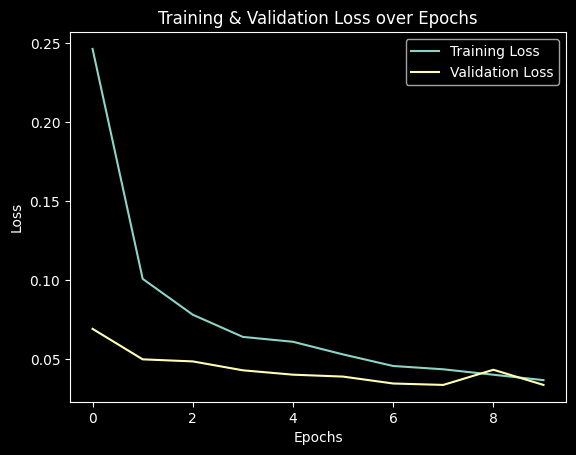

In [16]:
plt.plot(train_losses, label="Training Loss")
plt.plot(valid_losses, label="Validation Loss")

plt.title("Training & Validation Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Label-wise Accuracy

- 라벨(0~9)별로 test set 기준 accuracy를 계산 
- 특정 라벨에서 학습이 특히 잘 되었는지 / 추가 개선이 필요한지 확인


In [17]:
# 라벨(0~9)별 정답/전체 샘플수 집계
label_correct = torch.zeros(10)
label_total = torch.zeros(10)

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        for label in range(10):
            mask = labels == label
            label_total[label] += mask.sum().item()
            label_correct[label] += (predicted[mask] == labels[mask]).sum().item()

label_accuracy = (label_correct / label_total).tolist()

for label in range(10):
    print(
        f"Label {label}: "
        f"{int(label_correct[label])}/{int(label_total[label])} "
        f"({label_accuracy[label]:.4f})"
    )


Label 0: 979/980 (0.9990)
Label 1: 1133/1135 (0.9982)
Label 2: 1027/1032 (0.9952)
Label 3: 1006/1010 (0.9960)
Label 4: 973/982 (0.9908)
Label 5: 886/892 (0.9933)
Label 6: 946/958 (0.9875)
Label 7: 1020/1028 (0.9922)
Label 8: 963/974 (0.9887)
Label 9: 986/1009 (0.9772)


## Results

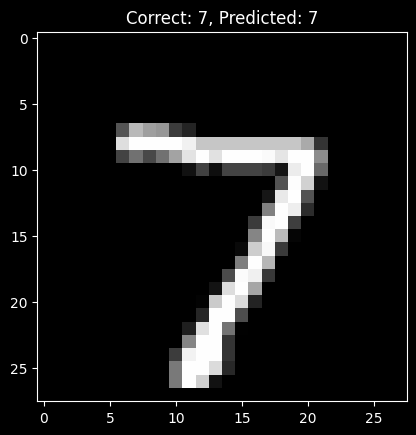

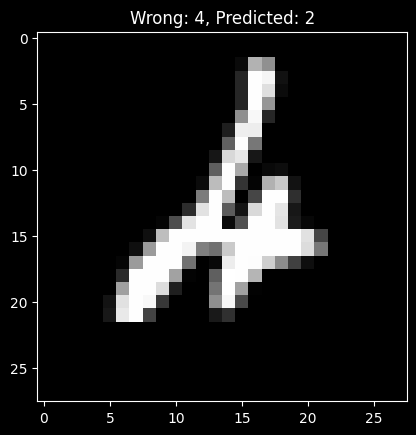

In [20]:
correct_sample = None
for i in range(len(test_set)):
    img, label = test_set[i]
    img_tensor = img.unsqueeze(0).to(device)
    output = model(img_tensor)
    _, pred = torch.max(output, 1)
    if pred.item() == label:
        correct_sample = (img, label, pred.item())
        break

if correct_sample:
    plt.imshow(correct_sample[0].squeeze(), cmap="gray")
    plt.title(f"Correct: {correct_sample[1]}, Predicted: {correct_sample[2]}")
    plt.show()

# 틀린 것
if misclassified_samples:
    img, pred, label = misclassified_samples[0]
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"Wrong: {label}, Predicted: {pred}")
    plt.show()

---
End of Documents